# 🍽️ Zomato Restaurant Performance Analysis

## 📌 Project Goal
This analysis was prepared to support business decisions for restaurant partners on the Zomato platform.
We aim to identify high-performing restaurants, detect underperformers, and provide actionable recommendations by city.

---

## 📂 Dataset
- **Source:** Zomato Restaurant Dataset (Kaggle)
- **Tool:** SQL (SQLite) + Python (Pandas, Matplotlib)

---

## 🗂️ Project Steps

### Step 1: Data Cleaning
- Remove missing, duplicate, and unnecessary data

### Step 2: Exploratory Data Analysis (EDA)
- Get familiar with the data
- Highest rated restaurants
- Most expensive cities
- Most bestseller items by restaurant

### Step 3: Performance Score
- Combine Dining Rating + Delivery Rating
- Weight by number of votes
- Rank restaurants by composite score

### Step 4: City Analysis
- Which cities perform well, which don't?
- Compare ratings and votes by city

### Step 5: Recommendations
- Actionable suggestions for restaurant partners
- Which restaurants need improvement and in which area?

---

## 🇹🇷 Proje Özeti (Türkçe)

### 📌 Amaç
Bu analiz, Zomato platformundaki restoran ortaklarına yönelik iş kararlarını desteklemek amacıyla hazırlanmıştır.
Yüksek performanslı restoranları tespit etmek, düşük performans gösterenleri belirlemek ve şehir bazında aksiyon önerileri sunmak hedeflenmektedir.

### 🗂️ Proje Adımları

**Adım 1: Veri Temizleme**
- Eksik, tekrarlı ve gereksiz verilerin temizlenmesi

**Adım 2: Keşifsel Veri Analizi**
- En yüksek puanlı restoranlar
- En pahalı şehirler
- En çok bestseller ürünü olan restoranlar

**Adım 3: Performans Skoru**
- Dining + Delivery rating birleştirme
- Oy sayısıyla ağırlıklandırma
- Bileşik skora göre sıralama

**Adım 4: Şehir Analizi**
- Hangi şehirler iyi, hangileri kötü?
- Şehir bazında rating ve oy karşılaştırması

**Adım 5: Öneriler**
- Restoran ortakları için aksiyon önerileri
- Hangi restoran hangi alanda gelişmeli?

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gauravkumar2525/zomato-restaurant-dataset/enhanced_zomato_dataset_clean.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/gauravkumar2525/zomato-restaurant-dataset/enhanced_zomato_dataset_clean.csv')
df.head()

,Restaurant_Name,Dining_Rating,Delivery_Rating,Dining_Votes,Delivery_Votes,Cuisine,Place_Name,City,Item_Name,Best_Seller,...,Is_Bestseller,Restaurant_Popularity,Avg_Rating_Restaurant,Avg_Price_Restaurant,Avg_Rating_Cuisine,Avg_Price_Cuisine,Avg_Rating_City,Avg_Price_City,Is_Highly_Rated,Is_Expensive
0,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Platter Kebab Combo,BESTSELLER,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0
1,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Rumali Shawarma,BESTSELLER,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0
2,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Tandoori Salad,NONE,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0
3,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken BBQ Salad,BESTSELLER,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0
4,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Special Doner Wrap Combo,MUST TRY,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0


In [3]:
import sqlite3
conn = sqlite3.connect(':memory:')
df.to_sql('restoranlar', conn, index=False)

123657

In [4]:
pd.read_sql("SELECT * FROM restoranlar LIMIT 5", conn)

,Restaurant_Name,Dining_Rating,Delivery_Rating,Dining_Votes,Delivery_Votes,Cuisine,Place_Name,City,Item_Name,Best_Seller,...,Is_Bestseller,Restaurant_Popularity,Avg_Rating_Restaurant,Avg_Price_Restaurant,Avg_Rating_Cuisine,Avg_Price_Cuisine,Avg_Rating_City,Avg_Price_City,Is_Highly_Rated,Is_Expensive
0,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Platter Kebab Combo,BESTSELLER,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0
1,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Rumali Shawarma,BESTSELLER,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0
2,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Tandoori Salad,NONE,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0
3,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken BBQ Salad,BESTSELLER,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0
4,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Special Doner Wrap Combo,MUST TRY,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0


***Adım 1: Veri Temizleme / Data Cleaning***

In [5]:
df.isnull().sum()

Restaurant_Name          0
Dining_Rating            0
Delivery_Rating          0
Dining_Votes             0
Delivery_Votes           0
Cuisine                  0
Place_Name               0
City                     0
Item_Name                0
Best_Seller              0
Votes                    0
Prices                   0
Average_Rating           0
Total_Votes              0
Price_per_Vote           0
Log_Price                0
Is_Bestseller            0
Restaurant_Popularity    0
Avg_Rating_Restaurant    0
Avg_Price_Restaurant     0
Avg_Rating_Cuisine       0
Avg_Price_Cuisine        0
Avg_Rating_City          0
Avg_Price_City           0
Is_Highly_Rated          0
Is_Expensive             0
dtype: int64

*Bu zaten temizlenmiş bir datasetti ama biz yine de kontrol ettik. / This was already a cleaned dataset, but we checked it anyway.*

**Adım 2: Keşifsel Veri Analizi / Exploratory Data Analysis(EDA)**

In [6]:
print("-------------------------------------")
print("--VERİMİZ HAKKINDA BİLGİLER / İNFO--")
print("-------------------------------------")
df.info()

-------------------------------------
--VERİMİZ HAKKINDA BİLGİLER / İNFO--
-------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123657 entries, 0 to 123656
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Restaurant_Name        123657 non-null  object 
 1   Dining_Rating          123657 non-null  float64
 2   Delivery_Rating        123657 non-null  float64
 3   Dining_Votes           123657 non-null  int64  
 4   Delivery_Votes         123657 non-null  int64  
 5   Cuisine                123657 non-null  object 
 6   Place_Name             123657 non-null  object 
 7   City                   123657 non-null  object 
 8   Item_Name              123657 non-null  object 
 9   Best_Seller            123657 non-null  object 
 10  Votes                  123657 non-null  int64  
 11  Prices                 123657 non-null  float64
 12  Average_Rating         123657

**1.** ***En yüksek puanlı restoranlar/highest-rated restaurants***

In [7]:
pd.read_sql(''' SELECT Restaurant_Name, Dining_Rating
                FROM restoranlar 
                GROUP BY Restaurant_Name
                ORDER BY Dining_Rating DESC
                LIMIT 10
''',conn)

,Restaurant_Name,Dining_Rating
0,Toscano,4.7
1,Thali and More,4.7
2,AB's - Absolute Barbecues,4.7
3,Urban Khichdi,4.6
4,Truffles,4.6
5,Exotica,4.6
6,Eating Circles,4.6
7,Cafe 17,4.6
8,Brik Oven,4.6
9,Kings Kulfi,4.5


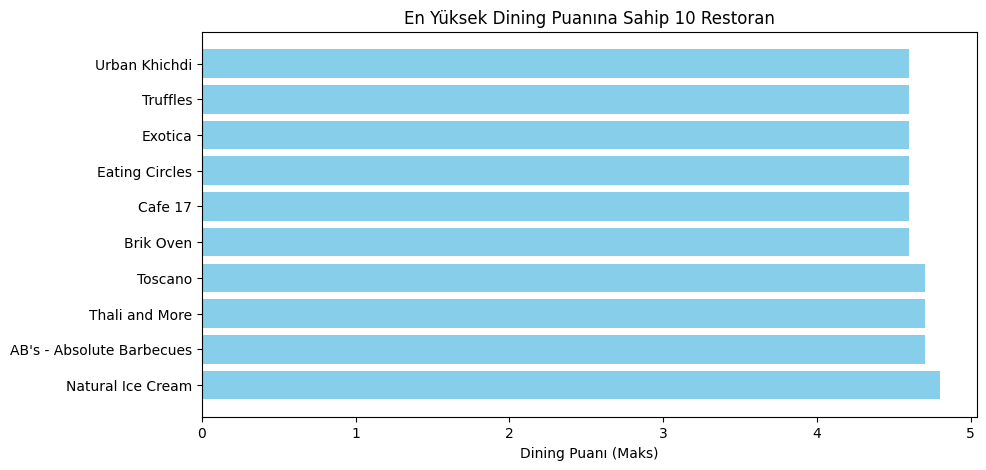

In [8]:
restoran_max = df.groupby('Restaurant_Name')['Dining_Rating'].max().reset_index()
top10_max = restoran_max.nlargest(10, 'Dining_Rating')

plt.figure(figsize=(10,5))
plt.barh(top10_max['Restaurant_Name'], top10_max['Dining_Rating'], color='skyblue')
plt.xlabel('Dining Puanı (Maks)')
plt.title('En Yüksek Dining Puanına Sahip 10 Restoran')
plt.show()

**2.** ***En pahalı restoranlar hangi şehirlerde bulunuyor? / Which city has the most expensive restaurants*?** 

In [9]:
pd.read_sql(''' SELECT City, AVG(Avg_Price_Restaurant) AS ortalama_fiyat
                FROM restoranlar 
                GROUP BY City
                ORDER BY ortalama_fiyat DESC
                LIMIT 10
''',conn)

,City,ortalama_fiyat
0,Ulsoor,663.359447
1,Banaswadi,335.893299
2,Mumbai,303.995891
3,Chennai,260.409220
4,Hyderabad,245.309399
5,Pune,241.824914
6,Kolkata,239.140947
7,New Delhi,234.816738
8,Lucknow,234.419230
9,Bangalore,233.621693


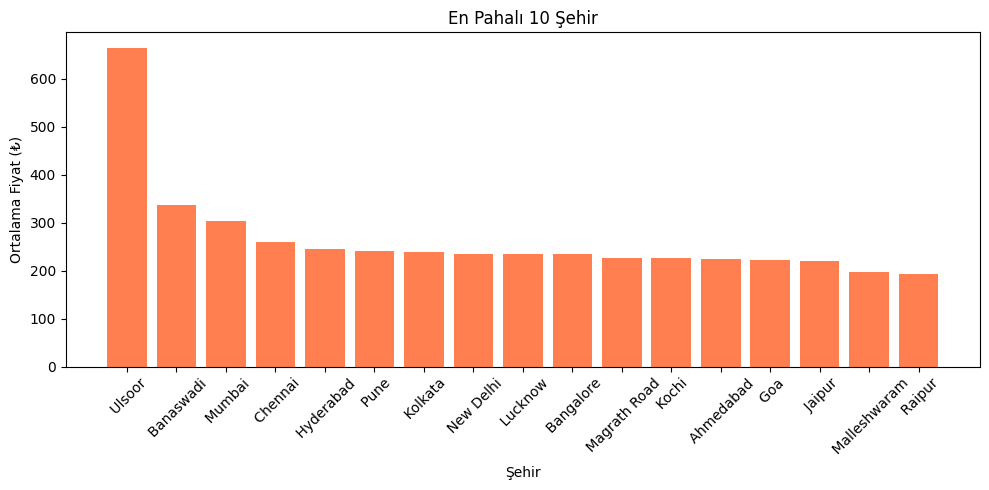

In [10]:
sehir_fiyat = df.groupby('City')['Avg_Price_Restaurant'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,5))
plt.bar(sehir_fiyat['City'], sehir_fiyat['Avg_Price_Restaurant'], color='coral')
plt.xlabel('Şehir')
plt.ylabel('Ortalama Fiyat (₺)')
plt.title('En Pahalı 10 Şehir')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*Ulsoor'daki diğer restoranlara nazaran çok pahalı gözüküyor. Düzeltemelere gidilebilir.*

*Compared to other restaurants in Ulsoor, it seems very expensive. Improvements could be made.*

**3.** ***Delivery rating'i düşük ama Dining rating'i yüksek restoranlar hangileri? → Teslimat hizmetini geliştirmesi gereken restoranlar hangileri? / "Which traditional delivery services have a low delivery rate but a high meal delivery rate?" → Who consistently needs to improve their delivery service?*** 

In [11]:
pd.read_sql(''' SELECT Restaurant_Name, MAX(Dining_Rating), MIN(Delivery_Rating)
                FROM restoranlar 
                GROUP BY Restaurant_Name
                LIMIT 10
''',conn)

,Restaurant_Name,MAX(Dining_Rating),MIN(Delivery_Rating)
0,12 To 12 BBQ,4.000000,4.0
1,1441 Pizzeria,3.822264,4.0
2,1944 -The HOCCO Kitchen,4.300000,4.3
3,4M Biryani House,4.100000,4.2
4,7 Plates,3.822264,4.3
5,99 Pancakes,3.800000,4.1
6,99 Variety Dosa & Pav Bhaji,3.900000,3.5
7,A Balaji Santosh Dhaba,3.700000,4.0
8,A-One Bombay Biryani,3.300000,3.5
9,A1 Ambur Briyani & Kababs,4.000000,3.7


*Şimdi farkı hesaplayalım ve en büyük farka göre sıralayalım / Now let's calculate the gap and sort by largest difference*

**Dining rating yüksek ama Delivery rating düşük olanlar / Those with high Dining ratings but low Delivery ratings**

In [12]:
fark_df = pd.read_sql(''' SELECT Restaurant_Name, MAX(Dining_Rating) AS dining, 
                MIN(Delivery_Rating) AS delivery,
                MAX(Dining_Rating) - MIN(Delivery_Rating) AS fark
                FROM restoranlar 
                GROUP BY Restaurant_Name
                ORDER BY fark DESC
                LIMIT 10
''',conn)
fark_df

,Restaurant_Name,dining,delivery,fark
0,Pizza Ricotta,3.822264,2.5,1.322264
1,AB's - Absolute Barbecues,4.700000,3.7,1.000000
2,Govind Dosa,4.400000,3.5,0.900000
3,Creams N Caffeine,4.300000,3.5,0.800000
4,Meltyway,4.200000,3.5,0.700000
5,The House Of Momo's,4.300000,3.6,0.700000
6,Onesta,4.300000,3.6,0.700000
7,Jay Bhavani Vadapav,3.900000,3.2,0.700000
8,Brik Oven,4.600000,3.9,0.700000
9,Winners Pizza - Fresh Dough,3.822264,3.2,0.622264


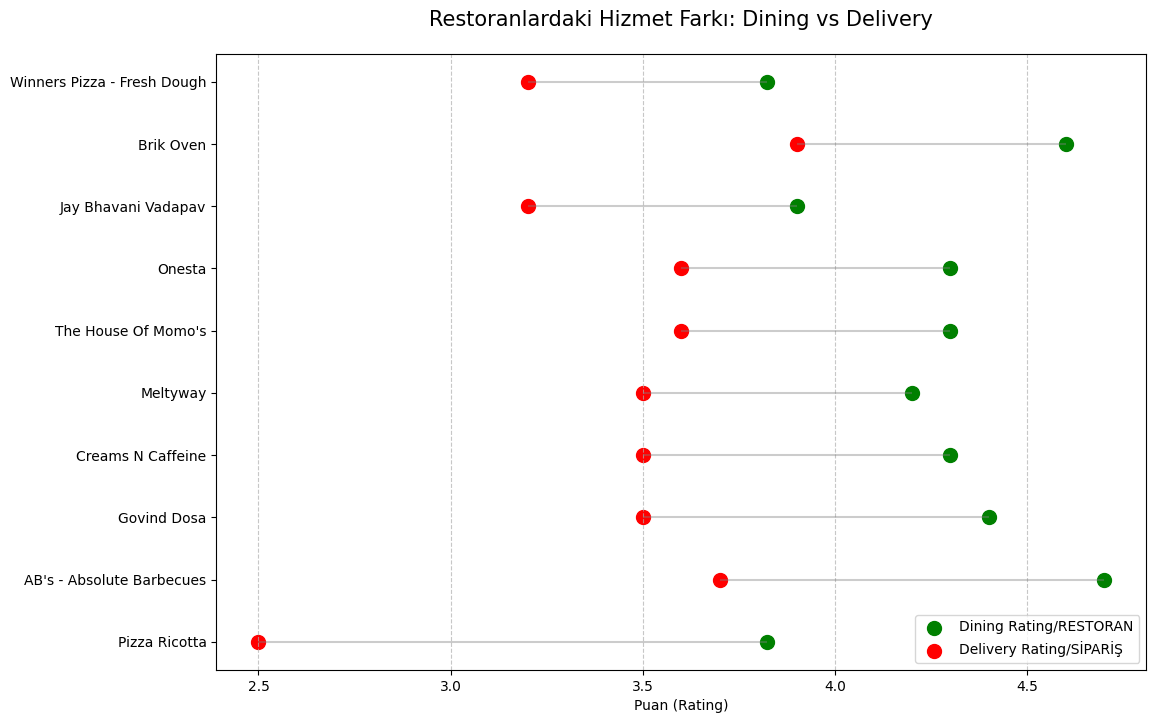

In [13]:
plt.figure(figsize=(12, 8))

plt.hlines(y=fark_df['Restaurant_Name'], xmin=fark_df['delivery'], xmax=fark_df['dining'], color='grey', alpha=0.4)
plt.scatter(fark_df['dining'], fark_df['Restaurant_Name'], color='green', label='Dining Rating/RESTORAN', s=100)
plt.scatter(fark_df['delivery'], fark_df['Restaurant_Name'], color='red', label='Delivery Rating/SİPARİŞ', s=100)

plt.title('Restoranlardaki Hizmet Farkı: Dining vs Delivery', fontsize=15, pad=20)
plt.xlabel('Puan (Rating)')
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

*Pizza Ricotta 1.32 farkla açık ara birinci gözüküyor. restorana gidince hizmet çok iyi ama siparişlerde kötü bir iş çıkartıyor.  Bu restoranların teslimat hizmetini geliştirmesi gerekiyor. / Pizza Ricotta is clearly in first place with a difference of 1.32 votes. The service at the restaurant is very good, but they do a poor job with delivery. These restaurants need to improve their delivery service.*

*AB's - Absolute Barbecue ve Brik Oven  restoranları, yemek kalitesinde mükemmele yakınlar. Bu, premium restoranların mekan avantajını paket serviste sürdüremediğini kanıtlar*

*AB's Absolute Barbecue and Brik Oven restaurants offer near-perfect food quality. This proves that premium restaurants cannot maintain their venue advantage in takeaway orders.*

*Listedeki 10 restoranın tamamında Yemek Puanı Teslimat Puanından fazla olduğu görülmektedir. Bu, paket servisin geç varış, yanlış sipariş, soğuk yemek gibi sıkıntıları olduğunu açıkca gösteren bir analizdir.*

*All 10 restaurants on the list show that the Food Score is higher than the Delivery Score. This analysis clearly indicates that takeaway services suffer from issues such as late arrivals, incorrect orders, and cold food.*

*Puan farkı fazla olan restoranlar için bir inceleme yapılmalıdır. Özellikle Pizza ve hızlı tüketim ürünleri gibi ürünlerin kutularının geliştirilmesi, sipariş tesliminin hızlandırılma çalışmaları bu farkı kapatabilir.*

*Restaurants with large point differences should be reviewed. Improvements to packaging, especially for products like pizza and fast-food items, and efforts to speed up delivery could help close this gap.*

**4. *En çok bestseller ürünü olan restoranlar hangileri? / Which restaurants have the most bestselling products?***

In [14]:
pd.read_sql(''' SELECT DISTINCT(Best_Seller) FROM restoranlar
''',conn)

,Best_Seller
0,BESTSELLER
1,NONE
2,MUST TRY
3,CHEF'S SPECIAL
4,SEASONAL
5,NOT ELIGIBLE FOR COUPONS
6,VEGAN
7,NOT ON PRO
8,SPICY
9,NEW


In [15]:
pd.read_sql('''SELECT Restaurant_Name, COUNT(Best_Seller) AS adet FROM restoranlar
            WHERE Best_Seller = 'BESTSELLER'
            GROUP BY Restaurant_Name
            ORDER BY COUNT(Best_Seller) DESC
            LIMIT 10
''', conn)

,Restaurant_Name,adet
0,Domino's Pizza,243
1,KFC,173
2,Subway,165
3,McDonald's,140
4,Burger King,134
5,La Pino'z Pizza,128
6,Pizza Hut,88
7,Rolls Mania,79
8,Rominus Pizza And Burger,75
9,Keventers - Milkshakes & Desserts,70


**5. Popülerlik vs Kalite: Domino's analizi / Popularity vs Quality: Domino's Analysis***

In [16]:
pd.read_sql(''' SELECT Restaurant_Name ,SUM(Dining_Votes) AS toplam_oy, MAX(Dining_Rating) AS yüksek_rating FROM restoranlar
                WHERE Restaurant_Name = "Domino's Pizza"
                GROUP BY Restaurant_Name
''', conn)

,Restaurant_Name,toplam_oy,yüksek_rating
0,Domino's Pizza,434194,3.9


**Dominos çok popülermiş ama puan olarak en yüksek puanlı restorant değil. En yüksek puanlı Natural Ice Cream'in kaç oyu var? / Domino's is very popular, but it's not a highly-rated restaurant in terms of ratings. How many votes does the highest-rated Natural Ice Cream have?**

In [17]:
pd.read_sql(''' SELECT Restaurant_Name ,SUM(Dining_Votes) AS toplam_oy, MAX(Dining_Rating) AS yüksek_rating FROM restoranlar
                WHERE Restaurant_Name = "Natural Ice Cream"
                GROUP BY Restaurant_Name
''', conn)

,Restaurant_Name,toplam_oy,yüksek_rating
0,Natural Ice Cream,12144,4.8


**Buradan da anlıyoruz ki çok oy çok puan getirmiyor. 
Burayı Gemini'ye sorduğumda bana şöyle bir bakış açısı kazandırdı: 
""Domino's yüksek hacimli bir operasyon yönetiyor, bu yüzden puanı standardize etmek için alt segmentlere ayırmalıyız"**

Buralarda SQL kullanmamın sebebi biraz da tabloyu tanıyabilmek, kafamda orturtabilmek ve ölçeklendirebilmek. Bundan sonrasında pandas analizlerine devam edebiliriz. / 
The reason I'm using SQL here is partly to get to know the table, understand it, and scale it. After this, we can continue with pandas analyses.

**Adım 3: Performans Skoru**

In [18]:
df["performance_score"] = (df["Dining_Rating"] + df["Delivery_Rating"]) / 2

In [19]:
df[["Restaurant_Name", "Dining_Rating", "Delivery_Rating", "performance_score"]].head(10)

,Restaurant_Name,Dining_Rating,Delivery_Rating,performance_score
0,Doner King,3.9,4.2,4.05
1,Doner King,3.9,4.2,4.05
2,Doner King,3.9,4.2,4.05
3,Doner King,3.9,4.2,4.05
4,Doner King,3.9,4.2,4.05
5,Doner King,3.9,4.2,4.05
6,Doner King,3.9,4.2,4.05
7,Doner King,3.9,4.2,4.05
8,Doner King,3.9,4.2,4.05
9,Doner King,3.9,4.2,4.05


*Veri setinde her satır bir yemek, biz ise her restoran için skor istedik. Bu bizi sıkıntıya sokabilir. Bunun için restoran başına ortalama alalım.*

*In the dataset, each row represents a dish, and we wanted a score for each restaurant. This could cause us problems. Therefore, let's take an average per restaurant.*

In [20]:
restaurant_summary = df.groupby('Restaurant_Name')[['Dining_Rating', 'Delivery_Rating', 'performance_score', 'Total_Votes']].mean()

top_10_restaurants = restaurant_summary.sort_values(by='performance_score', ascending=False).head(10)

top_10_restaurants

,Dining_Rating,Delivery_Rating,performance_score,Total_Votes
Restaurant_Name,,,,
Kings Kulfi,4.50000,4.4,4.45000,227.000000
Chaitanya,4.50000,4.4,4.45000,0.000000
Truffles,4.60000,4.3,4.45000,0.000000
Exotica,4.60000,4.3,4.45000,0.000000
Natural Ice Cream,4.30414,4.5,4.40207,231.314286
Al Taza,4.40000,4.4,4.40000,367.000000
Toscano,4.70000,4.1,4.40000,891.000000
Thali and More,4.70000,4.1,4.40000,0.000000
Boojee Cafe,4.50000,4.3,4.40000,319.000000


<Axes: title={'center': 'Restoran Bazlı Genel Performans'}, xlabel='Restaurant_Name'>

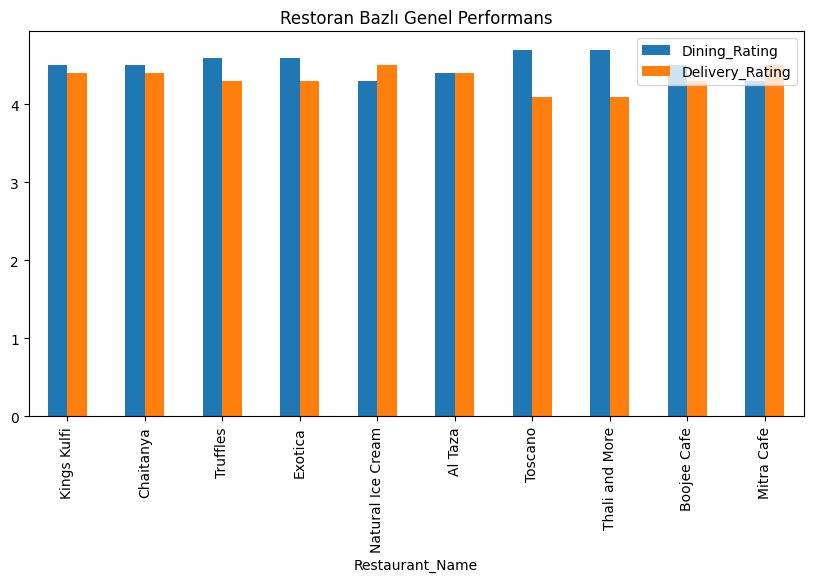

In [21]:
top_10_restaurants[['Dining_Rating', 'Delivery_Rating']].plot(kind='bar', figsize=(10,5), title="Restoran Bazlı Genel Performans")

*Yani en iyi dining puanı olan restoran, en yüksek performans skoruna sahip değil!*

*So the restaurant with the best dining rating doesn't necessarily have the highest performance score!*

In [22]:
df["weighted_score"] = df["performance_score"] * np.log(df["Total_Votes"] + 1)

> *Claude önerisi :log kullanıyoruz çünkü 100.000 oy ile 200.000 oy arasındaki fark çok da önemli değil, ama 10 oy ile 1000 oy arasındaki fark çok önemli.*

> *Claude's suggestion: We use log because the difference between 100,000 votes and 200,000 votes isn't that significant, but the difference between 10 votes and 1,000 votes is very significant.*

In [23]:
df.groupby("Restaurant_Name")["weighted_score"].mean().sort_values(ascending=False)

Restaurant_Name
Jimis Burger              30.754442
BurgerMan                 29.951967
Toscano                   29.891251
Zaffran Mataam Alarabi    29.683724
Annamaya                  29.562891
                            ...    
Art Of Dum                 0.000000
Arsalan                    0.000000
Aromas Cafe & Bistro       0.000000
Adhiya Beef Biriyani       0.000000
Acme Candy Food            0.000000
Name: weighted_score, Length: 826, dtype: float64

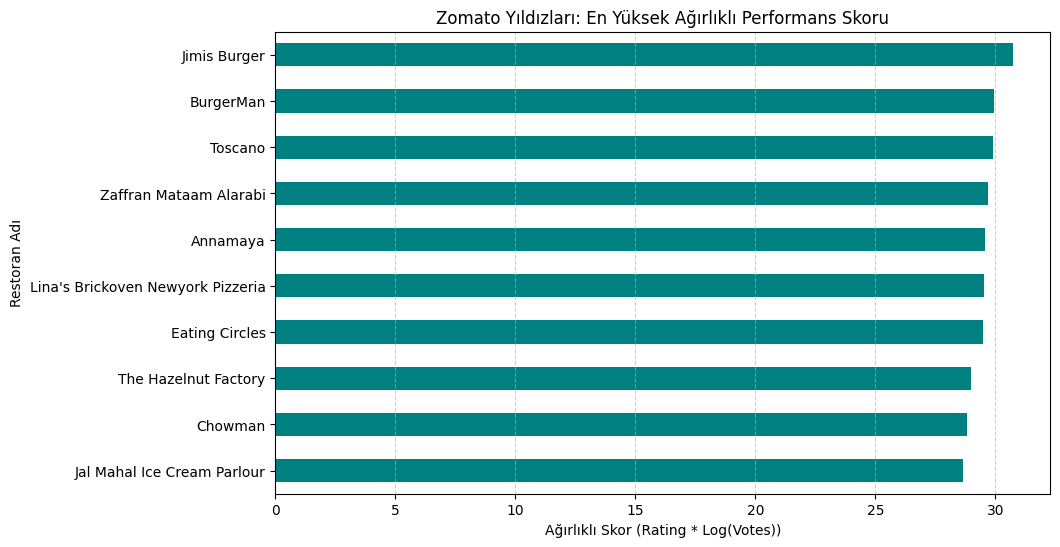

In [24]:
toplam_ = df.groupby("Restaurant_Name")["weighted_score"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
toplam_.plot(kind='barh', color='teal')

plt.title('Zomato Yıldızları: En Yüksek Ağırlıklı Performans Skoru')
plt.xlabel('Ağırlıklı Skor (Rating * Log(Votes))')
plt.ylabel('Restoran Adı')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

*Bu 10 restoran, platformumuzun "Güven Endeksi" en yüksek olan markalarıdır; pazarlama kampanyalarında öncelik verilmelidir*

*These 10 restaurants have the highest "Trust Index" on our platform; they should be prioritized in marketing campaigns.*

**Adım 4: Şehir Analizi / City Analysis**

***Hangi şehirler iyi, hangileri kötü? / Which cities are good, and which are bad?***

In [25]:
df.groupby("City")[["Dining_Rating", "Delivery_Rating", "performance_score"]].mean().sort_values("performance_score", ascending=False).head(10)

,Dining_Rating,Delivery_Rating,performance_score
City,,,
Malleshwaram,4.000000,4.000000,4.000000
New Delhi,3.937668,3.950057,3.943863
Hyderabad,3.878013,4.000049,3.939031
Ulsoor,3.822264,4.000000,3.911132
Lucknow,3.862373,3.956716,3.909544
Kolkata,3.837545,3.976483,3.907014
Goa,3.893852,3.902895,3.898374
Jaipur,3.782521,4.001839,3.892180
Chennai,3.819872,3.958954,3.889413


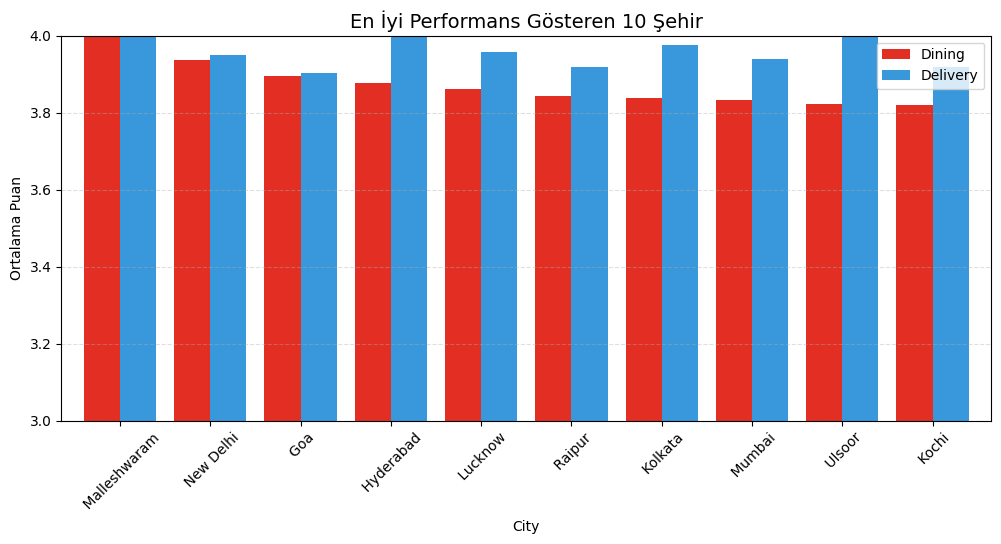

In [26]:
city_perf = df.groupby("City")[["Dining_Rating", "Delivery_Rating"]].mean().sort_values("Dining_Rating", ascending=False).head(10)

ax = city_perf.plot(kind='bar', figsize=(12, 5), color=['#e22e23', '#3898db'], width=0.8)

plt.title('En İyi Performans Gösteren 10 Şehir', fontsize=14)
plt.ylabel('Ortalama Puan')
plt.ylim(3, 4)
plt.xticks(rotation=45)
plt.legend(["Dining", "Delivery"])
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

*Şehirlerin çoğunda mekan ve paket değerleri birbirine çok yakın. Bu, o şehirlerdeki genel hizmet kalitesinin standartlaştığını gösterir.
Zomato'nun en prestijli restoranlarının bulunduğu şehirler bunlardır. Pazarlama kampanyalarını bu şehirlerdeki "Gurme" kitleye odaklayabiliriz.*

*In most cities, venue and package deals are very similar. This indicates that the overall quality of service in those cities has become standardized. These are the cities where Zomato's most prestigious restaurants are located. We can focus marketing campaigns on the "Gourmet" audience in these cities.*

***Şehir bazında rating ve oy karşılaştırması / City-based rating and vote comparison.***

In [27]:
df.groupby('City')[['Dining_Rating', 'Total_Votes']].agg(['mean', 'sum'])

Dining_Rating               Total_Votes         
                      mean           sum        mean      sum
City                                                         
Ahmedabad         3.787888  38553.122858  262.992729  2676740
Banaswadi         3.700000    358.900000  186.000000    18042
Bangalore         3.778522  45493.403006  215.431478  2593795
Chennai           3.819872  50040.318592  324.898702  4256173
Goa               3.893852   9189.491123  238.663559   563246
Hyderabad         3.878013  60547.416239  235.284891  3673503
Jaipur            3.782521  54612.036182  302.623701  4369281
Kochi             3.820084  29640.033770  274.550458  2130237
Kolkata           3.837545  33240.813356  253.259986  2193738
Lucknow           3.862373  24931.617150  336.658869  2173133
Magrath Road      3.500000    189.000000  112.000000     6048
Malleshwaram      4.000000    172.000000  746.000000    32078
Mumbai            3.833141  51881.562300  288.519246  3905108
New Delhi         3.937668  13742.461429  249.570774   871002
Pune              3.746046  30219.350703  237.109086  1912759
Raipur            3.842326  29585.907177  237.112468  1825766
Ulsoor            3.822264    252.269426    7.000000      462

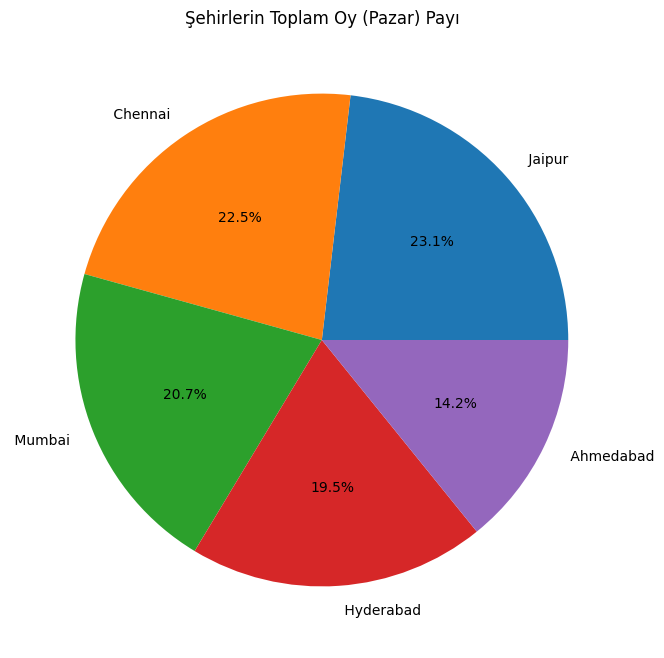

In [28]:
city_votes = df.groupby('City')['Total_Votes'].sum().sort_values(ascending=False).head(5)

city_votes.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8), title="Şehirlerin Toplam Oy (Pazar) Payı")
plt.ylabel('')
plt.show()

*Diğer şehirler toplamda ancak bir New Delhi ediyor. Operasyon merkezimizi New Delhi'de tutmalıyız*

*The other cities together only amount to one New Delhi. We must keep our operations center in New Delhi.*

**Adım 5: Öneriler / Suggestions**


**Öne Çıkarılacak Restoranlar / Highlighted Restaurants**

    Jimis Burger, hem yüksek rating hem de yüksek oy sayısıyla platformun en güvenilir restoranıdır. Pazarlama kampanyalarında öncelikli olarak öne çıkarılmalıdır.

    Jimis Burger is the most trusted restaurant on the platform, with both a high rating and a high number of votes. It should be prioritized in marketing campaigns.

**Teslimat Geliştirmesi Gereken Restoranlar / Restaurants That Need Delivery Improvement**
   
    Pizza Ricotta, dining rating'i yüksek ancak delivery rating'i platformun en düşüklerinden biridir. 
    Teslimat hızı, sıcaklık koruması ve paketleme kalitesi acil olarak gözden geçirilmelidir.

    Pizza Ricotta has a high dining rating but one of the lowest delivery ratings on the platform.
    Delivery speed, temperature maintenance, and packaging quality urgently need to be reviewed.

**Şehir Bazında Öneriler / City-Based Recommendations**
    
    Ulsoor, platformun en pahalı bölgesidir ancak restoran sayısı ve oy verisi oldukça sınırlıdır. 
    Fiyat politikası gözden geçirilmeli, erişilebilirlik artırılmalıdır.
    Jaipur en büyük pazar payına sahip şehirler arasındadır, buraya özel kampanyalar düzenlenmelidir.

    Ulsoor is the most expensive area on the platform, but the number of restaurants and rating data are quite limited.
    Pricing policy should be reviewed, and accessibility should be increased.
    Jaipur is among the cities with the largest market share; special campaigns should be organized for this area.

**Genel Platform Önerileri / General Platform Recommendations**

    - Teslimat süreçlerinde hız ve sıcaklık standartları belirlenmeli
    - Düşük delivery rating'li restoranlarla birebir görüşme yapılmalı
    - Yüksek hacimli ama düşük puanlı restoranlar için iyileştirme programı başlatılmalı

    - Speed and temperature standards should be established in delivery processes.
    - One-on-one meetings should be held with restaurants with low delivery ratings.
    - An improvement program should be initiated for high-volume but low-rated restaurants.